### ___Multi Response Phylogenetic Mixed Models `MR-PMM` using Markov Chain Monte Carlo generalized linear mixed models `MCMCglmm`___
----------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.0 (2026-04-24 ucrt)"


In [2]:
# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_tutorial.html
# https://benjamin-halliwell.github.io/MR-PMM/MR-PMM_euc_example_analysis.html

In [3]:
set.seed(2026 - 3 - 9)

suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("MCMCglmm")
    library("nlme")
    library("U.PhyloMaker")
    library("phylolm")
    library("geiger")
})

### ___1. Phylogeny___
---------------------------

In [10]:
megatree <- ape::read.tree("../../data/chapter2/uphylomaker/GBOTB.extended.TPL.tre") # TPL megatree
# the order info in the FRED 4.0 subset dataset wasn't cross checked!!!!
traits <- read.csv("../../data/chapter2/FRED/subsets/final_name_matched.csv") # FRED 4.0 subset with names reconciled with the megatree by hand
# this does not need programmatic name reconciliations
traits$binominal <- gsub(traits$binominal, pattern = ' ', replacement = '_')
synonyms <- read.csv("../../data/chapter2/wcvp/synonyms.csv") # WCVP synonyms

In [7]:
#---------------------------
# phylogeney construction
#---------------------------

# species, genus, family, species.relative, genus.relative
species_list <- data.frame(species = traits$binominal, genus = traits$F01286, family = NA, species.relative = NA, genus.relative = NA)
genus_list <- data.frame(genus = traits$F01286, family = traits$F01289) 
phy <- U.PhyloMaker::phylo.maker(sp.list = species_list, gen.list = genus_list, tree = megatree)

In [8]:
ape::write.tree(phy = phy$phylo, file = "../../data/chapter2/uphylomaker/FRED4_1301_species.tre")

In [22]:
stopifnot(all(traits[match(phy$phylo$tip.label, traits$binominal), ]$binominal == phy$phylo$tip.label))
traits <- traits[match(phy$phylo$tip.label, traits$binominal), ]
write.csv(traits, "../../data/chapter2/FRED/subsets/final_name_matched.csv", row.names = FALSE)

### ___2. Phylogenetic signal and pairwise relationships___
---------------------------

In [15]:
GEIGER_FITCONTINUOUS_MODEL_OPTIONS <- c("BM", "OU", "EB", "rate_trend", "lambda", "kappa", "delta", "mean_trend", "white")
PHYLOLM_PHYLOLM_MODEL_OPTIONS <- c("BM", "OUrandomRoot", "OUfixedRoot", "lambda", "kappa", "delta", "EB", "trend", "GC")

In [7]:
# this phylogeny needs to be fully bifurcating with no polytomies
tree <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301_species.tre") # the phylogeny of the 1301 FRED 4.0 subset species

In [8]:
ape::is.binary(tree)

[1] FALSE

In [10]:
ape::is.ultrametric(tree)

[1] TRUE

In [18]:
tree <- ape::multi2di(tree, random = FALSE) # split polytomies into binary 0 length branches

# make the phylogeny completely bifurcating by replacing 0 length branches
tree$edge.length[tree$edge.length <= 0] <- rnorm(n = sum(tree$edge.length == 0), mean = 1e-6, sd = 1e-8) # replace the 0 length edges with random noise
stopifnot(!sum(tree$edge.length <= 0)) # no more 0 length branches
# tree <- phytools::force.ultrametric(tree = tree, method = "extend") # this needs to be done after replacing the 0 length branches with small non zero noise

stopifnot(ape::is.binary(tree) && ape::is.ultrametric(tree))

traits <- read.csv("../../data/chapter2/FRED/subsets/final.csv", row.names = "binominal")

# repeat the taxonomic corrections
# traits[traits$F01286 %in% c("Parablechnum", "Lomaria", "Blechnopsis"), "F01286"] = "Blechnum"
# traits[traits$F01286 == "Pseudodiphasium", "F01286"] = "Lycopodium"
# traits[traits$F01286 %in% c("Richetia", "Rubroshorea"), "F01286"] = "Shorea"

# traits["binominal"] <- paste0(traits$F01286, '_', traits$F01287)
# stopifnot(length(traits$binominal)==length(tree$tip.label))
# stopifnot(sum(tree$tip.label %in% traits$binominal) == length(tree$tip.label))
# traits <- traits[match(tree$tip.label, traits$binominal), ] # name matching the dataset and the phylogeny

stopifnot(all(tree$tip.label==traits$binominal)) # the current traits dataset has already been name matched with the phylogeny!!!!!!!!

In [20]:
head(traits) # we need the binominal names as row names for phylolm::phylolm 

,F01286,F01289,F00679,F00727,F00709,state,state_source,synonym
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Ratibida_pinnata,Ratibida,Asteraceae,-0.8209806,4.025352,-2.120264,AM,"(Soudzilovskaia et al., 2020)","('Lepachys pinnata', 'Rudbeckia pinnata', 'Helianthus pinnatus', 'Obeliscaria pinnata')"
Heliopsis_helianthoides,Heliopsis,Asteraceae,-0.9675840,4.158883,-1.966113,AM,"(Brundrett and Tedersoo, 2018)","('Buphthalmum helianthoides',)"
Liatris_aspera,Liatris,Asteraceae,-0.7985077,4.382027,-2.525729,AM,Maherali et. al. 2016,"('Lacinaria scariosa var. aspera', 'Lacinaria aspera')"
Arnica_sororia,Arnica,Asteraceae,-1.4134600,4.342257,-1.203973,AM,"(Soudzilovskaia et al., 2020)","('Arnica fulgens var. sororia',)"
Arnica_fulgens,Arnica,Asteraceae,-0.6627150,2.765172,-1.124452,AM,Maherali et. al. 2016,"('Arnica montana var. fulgens',)"
Hymenoxys_richardsonii,Hymenoxys,Asteraceae,-1.2644308,4.235371,-1.460061,AM,"(Soudzilovskaia et al., 2020)","('Picradenia richardsonii', 'Actinea richardsonii', 'Actinella richardsonii')"



Call:
phylolm::phylolm(formula = F00727 ~ F00679, data = traits, phy = tree, 
    model = "BM")

   AIC logLik 
  4341  -2167 

Raw residuals:
    Min      1Q  Median      3Q     Max 
-2.9928 -0.7258 -0.3513  0.0897  2.6076 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
sigma2: 0.09009283 

Coefficients:
             Estimate    StdErr  t.value p.value    
(Intercept)  2.213615  2.511175   0.8815  0.3782    
F00679      -1.704971  0.049048 -34.7615  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.4819	Adjusted R-squared: 0.4815 

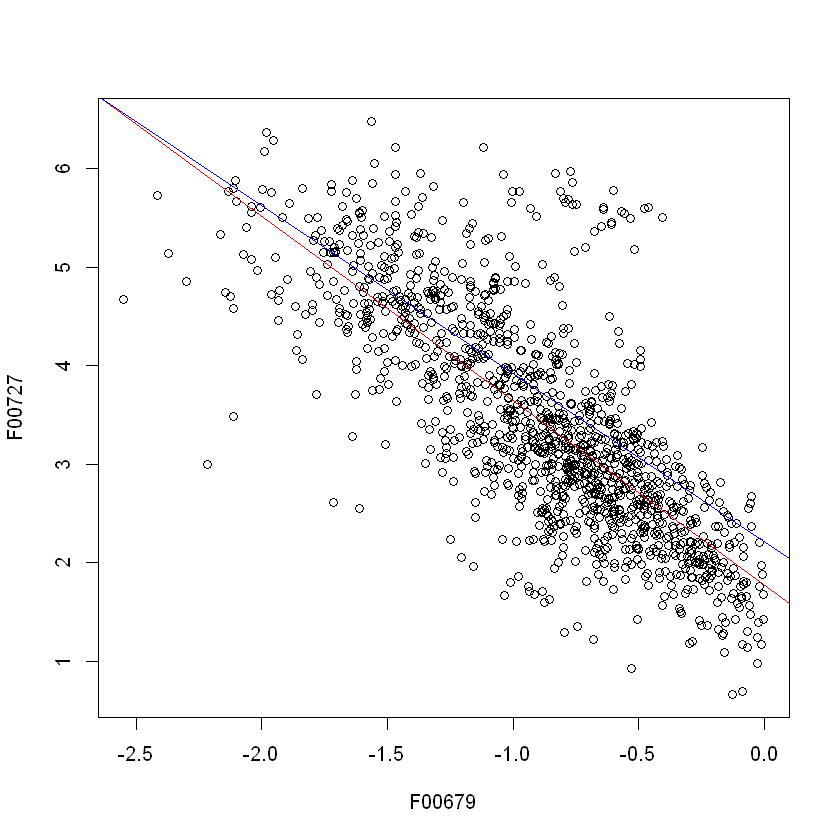

In [32]:
# log(SRL) ~ log(RD) (RD as the predictor of SRL)
#--------------------------------------------------

plot(F00727 ~ F00679, data = traits)
mod <- lm(F00727 ~ F00679, data = traits) # SRL ~ RD shows significant relationship with a strong R2
modp <- phylolm::phylolm(F00727 ~ F00679, data = traits, model = "BM", phy = tree) 
abline(mod, col = "red")
abline(modp, col = "blue")
summary(modp)


Call:
lm(formula = F00727 ~ F00709, data = traits)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.99195 -0.66289 -0.07818  0.65717  2.79274 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.10902    0.05818   36.25   <2e-16 ***
F00709      -1.01337    0.03980  -25.46   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.9304 on 1299 degrees of freedom
Multiple R-squared:  0.3329,	Adjusted R-squared:  0.3324 
F-statistic: 648.4 on 1 and 1299 DF,  p-value: < 2.2e-16


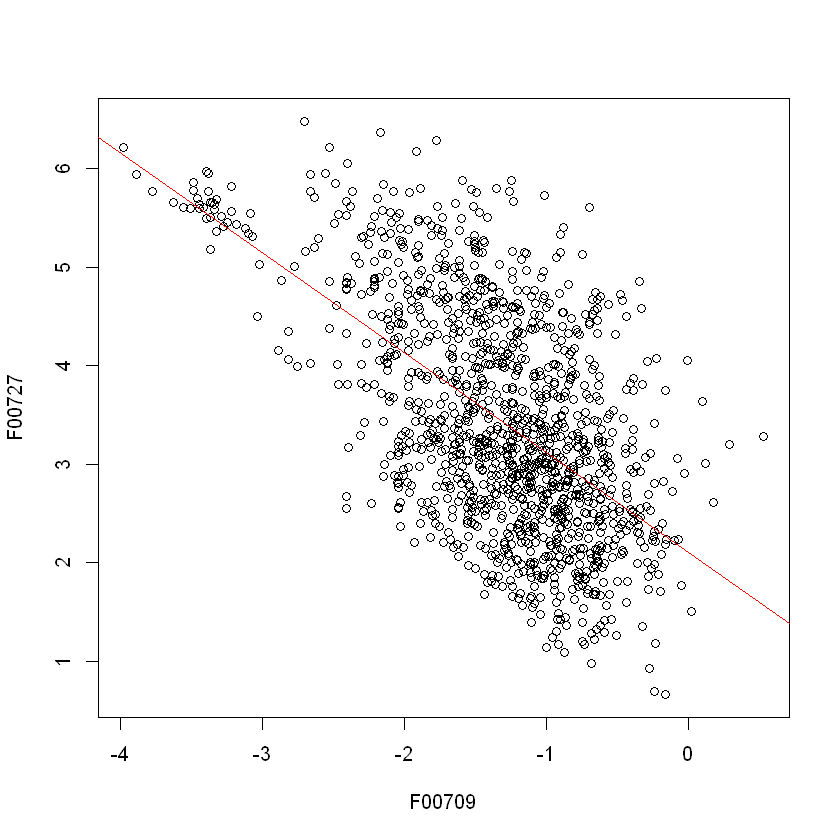

In [28]:
plot(F00727 ~ F00709, data = traits)
mod <- lm(F00727 ~ F00709, data = traits) # SRL ~ RTD also shows significant relationship with a strong R2
abline(mod, col = "red")
summary(mod)


Call:
lm(formula = F00679 ~ F00709, data = traits)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.67222 -0.28954  0.05228  0.33597  0.88826 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.86747    0.02908 -29.827   <2e-16 ***
F00709       0.01546    0.01989   0.777    0.437    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.4651 on 1299 degrees of freedom
Multiple R-squared:  0.0004649,	Adjusted R-squared:  -0.0003046 
F-statistic: 0.6042 on 1 and 1299 DF,  p-value: 0.4371


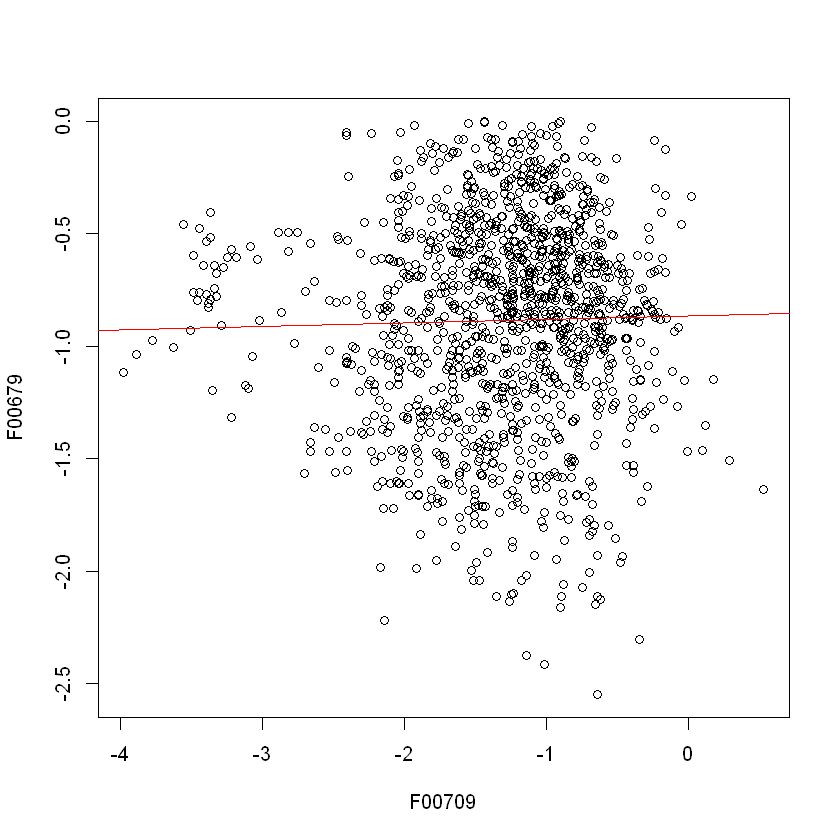

In [29]:
plot(F00679 ~ F00709, data = traits)
mod <- lm(F00679 ~ F00709, data = traits) # RD ~ RTD shows insignificant relationship with a very low R2
abline(mod, col = "red")
summary(mod)

In [21]:
# the tutorial uses the R library phylolm
# nlme::gls requires a correlation matrix - ape provides only limited options (Brownian, Bloomberg, Pagel et.c.) for this



Warning message in phylolm::phylolm(F00727 ~ F00679, data = traits, model = "OUrandomRoot", :
"the estimation of alpha matches the upper/lower bound for this parameter.
                          You may change the bounds using options "upper.bound" and "lower.bound".
"


Call:
phylolm::phylolm(formula = F00727 ~ F00679, data = traits, phy = tree, 
    model = "OUrandomRoot")

   AIC logLik 
  2918  -1455 

Parameter estimate(s) using ML:
alpha: 0.1247543
sigma2: 0.164423 

Coefficients:
(Intercept)      F00679 
   1.825333   -1.778975 

Warning message in Initialize.corPhyl(X[[i]], ...):
"No covariate specified, species will be taken as ordered in the data frame. To avoid this message, specify a covariate containing the species names with the 'form' argument."


In [57]:
# don't worry about the waring as our data and phylogeny has been name matched
summary(pgls)

Generalized least squares fit by REML
  Model: F00727 ~ F00679 
  Data: traits 
       AIC      BIC    logLik
  4341.423 4356.931 -2167.711

Correlation Structure: corBrownian
 Formula: ~1 
 Parameter estimate(s):
numeric(0)

Coefficients:
                Value Std.Error   t-value p-value
(Intercept)  2.213602 2.5113578   0.88144  0.3782
F00679      -1.704987 0.0490483 -34.76138  0.0000

 Correlation: 
       (Intr)
F00679 0.016 

Standardized residuals:
        Min          Q1         Med          Q3         Max 
-0.49763901 -0.12067620 -0.05840864  0.01491596  0.43358737 

Residual standard error: 6.014064 
Degrees of freedom: 1301 total; 1299 residual

In [19]:
# lapply(X = GEIGER_FITCONTINUOUS_MODEL_OPTIONS, FUN = function(m) {
#         geiger::fitContinuous(phy = tree, dat = setNames(traits$F00727, nm = traits$binominal), model = m)$opt
#     }
# )

tm <- Sys.time()

SRL_model_fits <- list()
RD_model_fits <- list()
RTD_model_fits <- list()

for (m in GEIGER_FITCONTINUOUS_MODEL_OPTIONS) {
    SRL_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = setNames(traits$F00727, nm = traits$binominal), model = m)
    RD_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = setNames(traits$F00679, nm = traits$binominal), model = m)
    RTD_model_fits[[m]] <- geiger::fitContinuous(phy = tree, dat = setNames(traits$F00707, nm = traits$binominal), model = m)
}

tm <- Sys.time() - tm

save(SRL_model_fits, RD_model_fits, RTD_model_fits, file = "../../data/chapter2/rdata/SRL_RD_RTD_geiger_fitContinuous.RData")

Warning message in geiger::fitContinuous(phy = tree, dat = setNames(traits$F00727, :
"Non-ultrametric tree with OU model, using VCV method."
Warning message in cache$dat - mu:
"Recycling array of length 1 in vector-array arithmetic is deprecated.
  Use c() or as.vector() instead."
Warning message in cache$dat - mu:
"Recycling array of length 1 in vector-array arithmetic is deprecated.
  Use c() or as.vector() instead."
Warning message in geiger::fitContinuous(phy = tree, dat = setNames(traits$F00679, :
"Non-ultrametric tree with OU model, using VCV method."
Warning message in cache$dat - mu:
"Recycling array of length 1 in vector-array arithmetic is deprecated.
  Use c() or as.vector() instead."
Warning message in cache$dat - mu:
"Recycling array of length 1 in vector-array arithmetic is deprecated.
  Use c() or as.vector() instead."


ERROR: Error in names(object) <- nm: attempt to set an attribute on NULL


In [20]:
tm

[1] "2026-05-31 10:10:57 +0530"

In [16]:
lapply(SRL_model_fits, function(m) m$opt)

[[1]]
[[1]]$sigsq
[1] 0.006444724

[[1]]$SE
[1] 0.7179027

[[1]]$z0
[1] 3.560547

[[1]]$lnL
[1] -1702.854

[[1]]$method
[1] "L-BFGS-B"

[[1]]$k
[1] 3

[[1]]$aic
[1] 3411.708

[[1]]$aicc
[1] 3411.727


[[2]]
[[2]]$sigsq
[1] 0.006444707

[[2]]$SE
[1] 0.7179042

[[2]]$z0
[1] 3.560547

[[2]]$lnL
[1] -1702.854

[[2]]$method
[1] "subplex"

[[2]]$k
[1] 3

[[2]]$aic
[1] 3411.708

[[2]]$aicc
[1] 3411.727


[[3]]
[[3]]$sigsq
[1] 0.006445058

[[3]]$SE
[1] 0.717904

[[3]]$z0
[1] 3.560548

[[3]]$lnL
[1] -1702.854

[[3]]$method
[1] "subplex"

[[3]]$k
[1] 3

[[3]]$aic
[1] 3411.708

[[3]]$aicc
[1] 3411.727


[[4]]
[[4]]$sigsq
[1] 0.006444536

[[4]]$SE
[1] 0.7178981

[[4]]$z0
[1] 3.560547

[[4]]$lnL
[1] -1702.854

[[4]]$method
[1] "subplex"

[[4]]$k
[1] 3

[[4]]$aic
[1] 3411.708

[[4]]$aicc
[1] 3411.727


[[5]]
[[5]]$sigsq
[1] 0.006444561

[[5]]$SE
[1] 0.7179001

[[5]]$z0
[1] 3.560547

[[5]]$lnL
[1] -1702.854

[[5]]$method
[1] "subplex"

[[5]]$k
[1] 3

[[5]]$aic
[1] 3411.708

[[5]]$aicc
[1] 3411.727


[[6]]
[[6]]$sigsq
[1] 0.006444557

[[6]]$SE
[1] 0.7178991

[[6]]$z0
[1] 3.560547

[[6]]$lnL
[1] -1702.854

[[6]]$method
[1] "subplex"

[[6]]$k
[1] 3

[[6]]$aic
[1] 3411.708

[[6]]$aicc
[1] 3411.727


[[7]]
[[7]]$sigsq
[1] 0.006444721

[[7]]$SE
[1] 0.7179011

[[7]]$z0
[1] 3.560548

[[7]]$lnL
[1] -1702.854

[[7]]$method
[1] "subplex"

[[7]]$k
[1] 3

[[7]]$aic
[1] 3411.708

[[7]]$aicc
[1] 3411.727


[[8]]
[[8]]$sigsq
[1] 0.006444916

[[8]]$SE
[1] 0.717904

[[8]]$z0
[1] 3.560548

[[8]]$lnL
[1] -1702.854

[[8]]$method
[1] "subplex"

[[8]]$k
[1] 3

[[8]]$aic
[1] 3411.708

[[8]]$aicc
[1] 3411.727


[[9]]
[[9]]$sigsq
[1] 0.006444722

[[9]]$SE
[1] 0.7179027

[[9]]$z0
[1] 3.560547

[[9]]$lnL
[1] -1702.854

[[9]]$method
[1] "L-BFGS-B"

[[9]]$k
[1] 3

[[9]]$aic
[1] 3411.708

[[9]]$aicc
[1] 3411.727

In [24]:
#--------------------
# phylolm::phylolm
#--------------------

traits_named <- traits # making a copy
rownames(traits_named) <- traits_named$binominal # phylolm requires that the rownames of the data matches with the tips of the phylogeny

# we know from our model comparison that RD, SRL and probably RTD are best explained by an OU process

pgls_1_brownian <- phylolm::phylolm(F00727 ~ F00679, data = traits_named, phy = phylogeny, model = "OUfixedRoot")
pgls_1_lambda <- phylolm::phylolm(F00727 ~ F00679, data = traits_named, phy = phylogeny, model = "OUrandomRoot")

In [25]:
summary(pgls_1_brownian) # this is very similar to what we got from nlme::gls()


Call:
phylolm::phylolm(formula = F00727 ~ F00679, data = data_phylolm, 
    phy = phylogeny, model = "BM")

   AIC logLik 
  3808  -1901 

Raw residuals:
    Min      1Q  Median      3Q     Max 
-8.0227 -0.5381 -0.0605  0.4830  2.4283 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
sigma2: 0.1349366 

Coefficients:
             Estimate    StdErr  t.value p.value    
(Intercept)  2.603773  3.101705   0.8395  0.4014    
F00679      -1.254196  0.073415 -17.0836  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.2271	Adjusted R-squared: 0.2264 

In [26]:
summary(pgls_1_lambda)


Call:
phylolm::phylolm(formula = F00727 ~ F00679, data = data_phylolm, 
    phy = phylogeny, model = "lambda")

   AIC logLik 
  2449  -1221 

Raw residuals:
    Min      1Q  Median      3Q     Max 
-8.2950 -0.4969 -0.0456  0.4195  2.6135 

Mean tip height: 400.7877
Parameter estimate(s) using ML:
lambda : 0.6740991
sigma2: 0.003957272 

Coefficients:
             Estimate    StdErr  t.value   p.value    
(Intercept)  2.269711  0.467750   4.8524 1.416e-06 ***
F00679      -1.569916  0.063468 -24.7355 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-squared: 0.3812	Adjusted R-squared: 0.3806 

Note: p-values and R-squared are conditional on lambda=0.6740991.

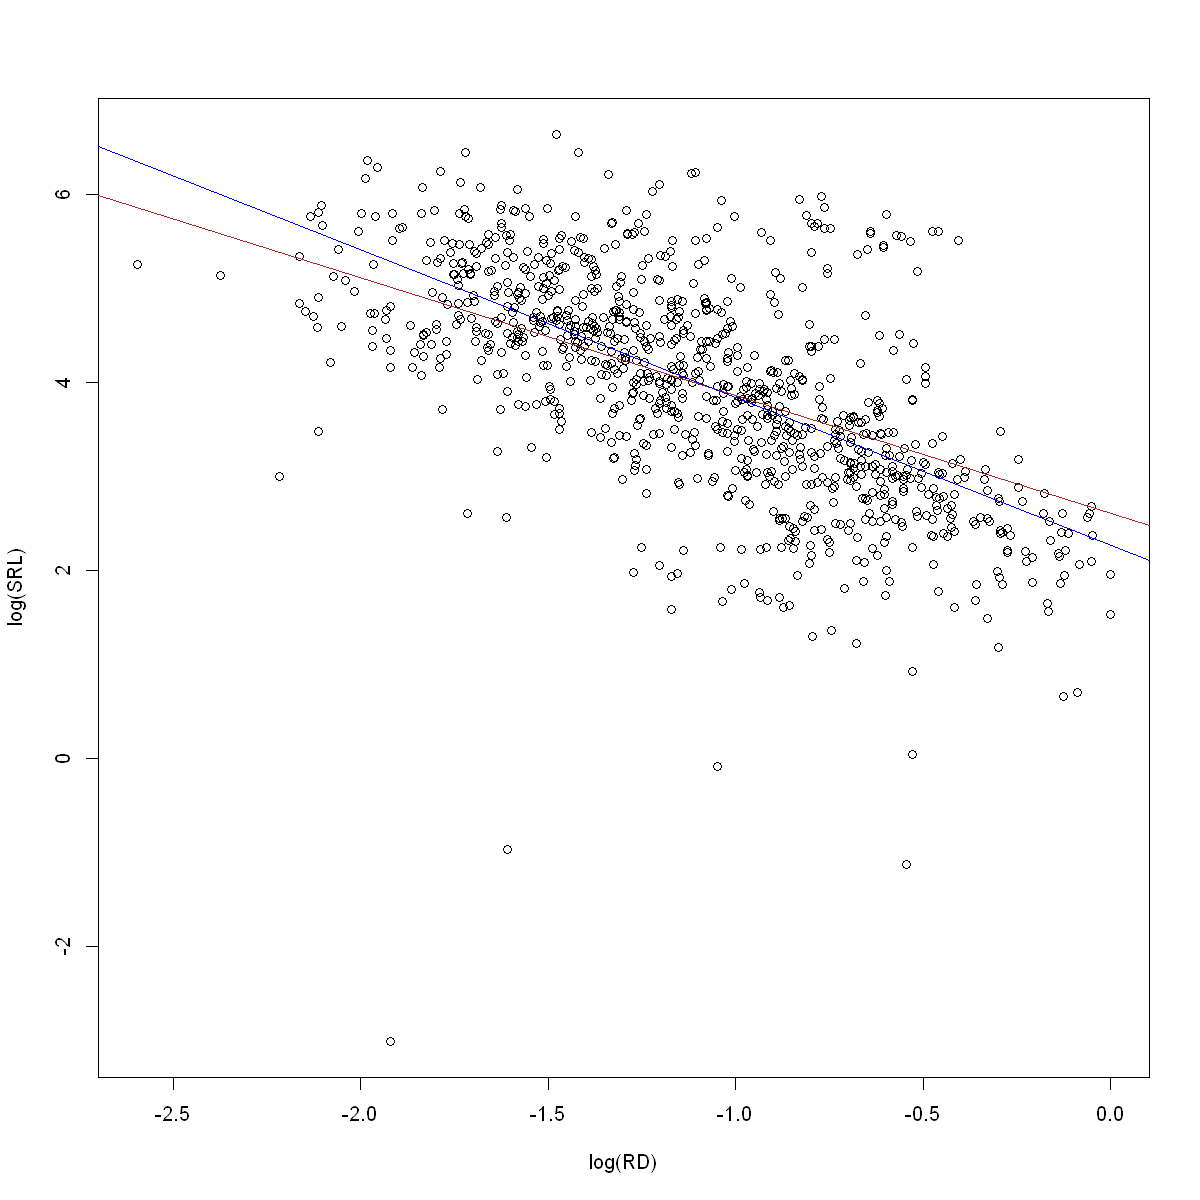

In [43]:
# these are all PGLS models, that account for phylogenetic signal in the response variables

options(repr.plot.width = 10, repr.plot.height = 10)
plot(F00727 ~ F00679, data, xlab = "log(RD)", ylab = "log(SRL)")
abline(pgls_0, col = "red")
abline(pgls_1_brownian, col = "brown") # the results of nlme::gls() and phylolm::phylolm() with 'method' arg set to "BM" are identical :)
abline(pgls_1_lambda, col = "blue")

In [46]:
# what if we fit a regular OLS model to the same data??

lmod <- lm(F00727 ~ F00679, data = data)
summary(lmod)


Call:
lm(formula = F00727 ~ F00679, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.2519 -0.4495  0.0052  0.4657  2.6655 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.21501    0.07453   29.72   <2e-16 ***
F00679      -1.57593    0.06258  -25.18   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.9104 on 993 degrees of freedom
Multiple R-squared:  0.3897,	Adjusted R-squared:  0.3891 
F-statistic: 634.2 on 1 and 993 DF,  p-value: < 2.2e-16


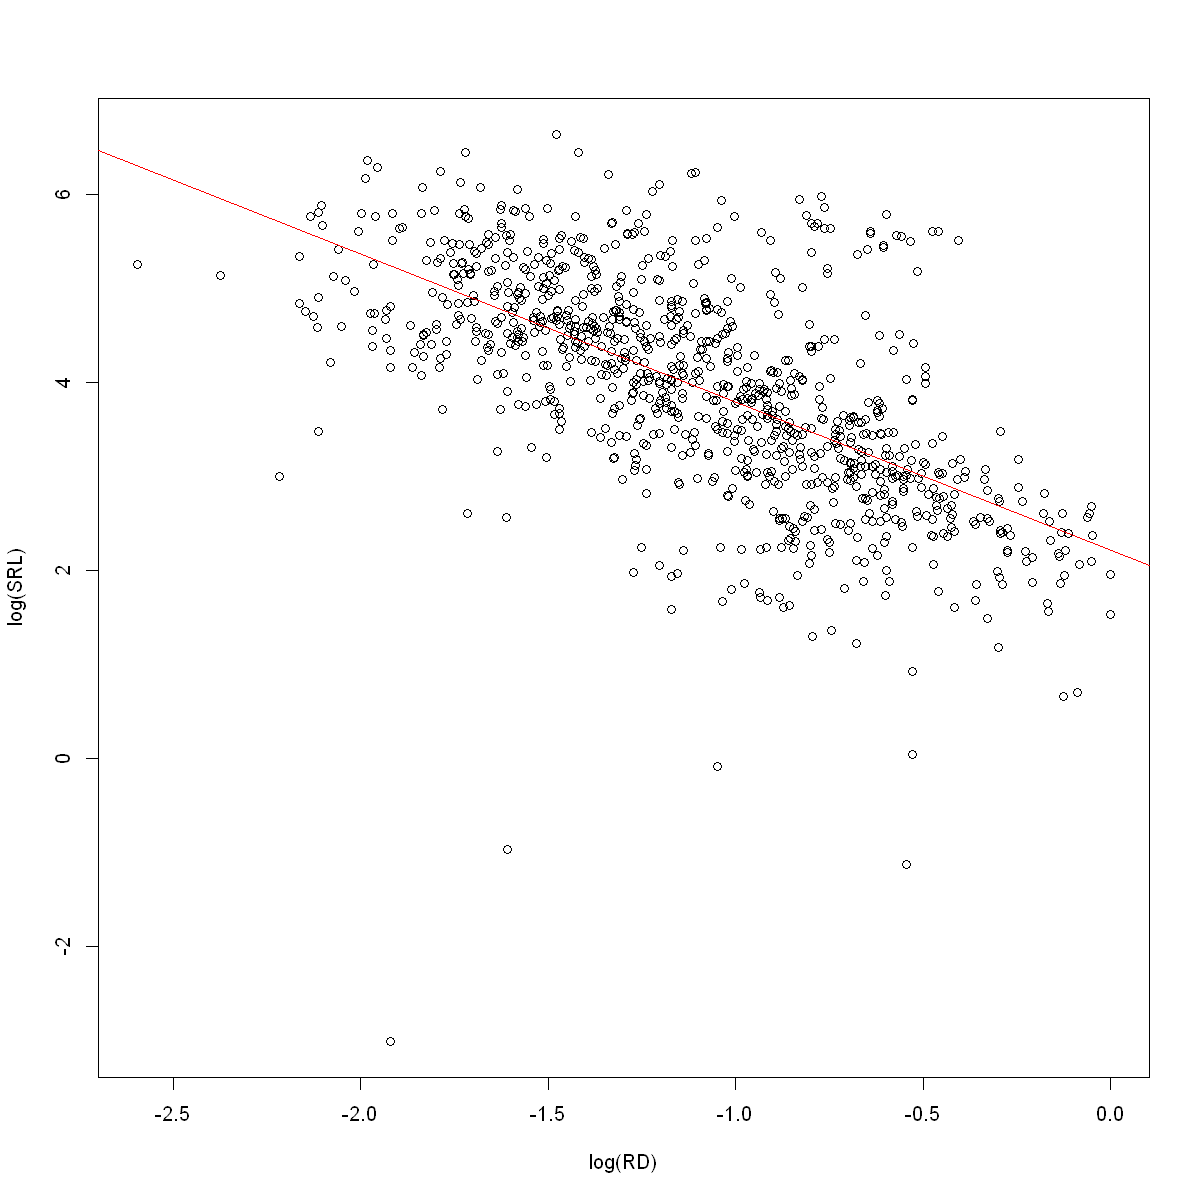

In [47]:
options(repr.plot.width = 10, repr.plot.height = 10)
plot(F00727 ~ F00679, data, xlab = "log(RD)", ylab = "log(SRL)")
abline(lmod, col = "red")

In [8]:
# "By including more diverse species in our phylogeny, we capture deeper splits that represent more meaningful divergences in the genotype and phenotype of extant lineages,
# precisely the effects we intend to model when analysing inter-species data."
# "One consequence of this, is that shallow topology (near the tips) is less informative than deep topology when attempting to infer patterns of phylogenetic niche conservatism, because differences between genera
# are usually more significant than differences between species within genera."

# "For higher taxonomic ranks (e.g. genus), it will usually be possible to derive a unique consensus tree by sampling a single species from each genus and simply pruning off the other tips from the tree.
# This approach may be problematic for lower taxonomic ranks however, because more closely related species are less likely to be monophyletic with respect to the taxonomic rank in question.
# Even in such cases, we can easily account for this phylogenetic uncertainty by randomly sampling topologies at the specified rank and fitting our models over this sample of trees."

In [16]:
# sample the phylogeny repeatedly, with one randomly chosen species per genera

NUNIQUE_GENERA <- length(unique(data$F01286)) # number of unique genera in our phylogeny
NSAMPLES = 100 # number of times to sample the original phylogeny
sampled_phylogenies <- list() # sampled sub phylogeneies with genera at tips
sampled_vcvs <- list()

for (i in 1:NSAMPLES) {
    sampled_species <- mapply(split.data.frame(data[, c("binominal", "F01286")], ~F01286), FUN = function(df) sample(df$binominal, 1)) # this is a vector of one randomly sampled species per each genera in the phylogeny
    subphylogeny <- ape::keep.tip(phy = phylogeny, tip = unname(sampled_species), trim.internal = TRUE) # trimmed phylogeny with one randomly sampled species per genus
    stopifnot(length(subphylogeny$tip.label)==NUNIQUE_GENERA)
                                     
    if(!ape::is.binary(subphylogeny)) subphylogeny <- ape::multi2di(subphylogeny) # make bifucracting if not already
    if(!ape::is.ultrametric(subphylogeny)) subphylogeny <- phytools::force.ultrametric(subphylogeny, method = "extend", message = FALSE) # make ultrametric if not already

    subphylogeny$tip.label <- gsub(subphylogeny$tip.label, pattern = "_[-a-z]+", replacement = '', fixed = FALSE) # replace the tip labels (binominal names) with genus names
    stopifnot(length(setdiff(subphylogeny$tip.label, unique(data$F01286))) == 0)
                              
    sampled_phylogenies[[i]] <- subphylogeny
    sampled_vcvs[[i]] <- ape::vcv.phylo(phy = subphylogeny, corr = TRUE) # computes the expected variances and covariances of a continuous phenotype assuming it evolves under a Brownian motion model
}

stopifnot(length(sampled_phylogenies) == length(sampled_vcvs))

In [ ]:
# create list of C matrices and dfs for use with brm_multiple() - DONT KNOW WTF THESE ARE????